In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv(r"C:\Users\puruc\Downloads\House Price Prediction\STEP - 2 (Data Cleaning)\5 - Missing Value\gurgaon_properties_missing_value_imputation.csv")

In [4]:
df.shape

(3514, 20)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,3,3,0,0.0,Moderately Old,2992.86,2667.0,2400.03,0,0,0,0,0,1,22
1,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,3,3,3,2.0,Relatively New,1650.00,1524.0,1399.95,1,1,0,0,0,1,136
2,flat,puri diplomatic greens,sector 111,2.25,13235.0,3,3,2,12.0,Relatively New,1700.05,1539.0,1385.00,0,0,0,0,0,0,101
3,flat,signature andour heights,sector 71,0.60,10000.0,2,2,1,5.0,Relatively New,599.98,557.0,513.98,0,0,0,1,0,0,59
4,flat,bestech park view residency,sector 2,1.40,7865.0,3,3,3+,8.0,Moderately Old,1780.03,1611.0,1450.00,0,0,0,0,0,0,92


In [7]:
latlong = pd.read_csv("latlong.csv")

In [8]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [9]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [10]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [11]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [12]:
new_df = df.merge(latlong, on='sector')

In [13]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury_score', 'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [14]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252 entries, 0 to 3251
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3252 non-null   object 
 1   society              3252 non-null   object 
 2   sector               3252 non-null   object 
 3   price                3252 non-null   float64
 4   price_per_sqft       3252 non-null   float64
 5   bedRoom              3252 non-null   int64  
 6   bathroom             3252 non-null   int64  
 7   balcony              3252 non-null   object 
 8   floorNum             3252 non-null   float64
 9   agePossession        3252 non-null   object 
 10  super_built_up_area  3252 non-null   float64
 11  built_up_area        3252 non-null   float64
 12  carpet_area          3252 non-null   float64
 13  study room           3252 non-null   int64  
 14  servant room         3252 non-null   int64  
 15  store room           3252 non-null   i

In [15]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()

In [16]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.888889,3056.163333,28.4484,77.0210
manesar,0.961515,4717.606061,1994.850909,28.3515,76.9428
sector 1,1.860000,8249.500000,2327.831667,28.3663,76.9456
sector 102,1.696636,10603.719626,1556.096168,28.4750,76.9715
sector 103,1.495000,7445.476190,1865.447857,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.913838,5897.070707,1542.749091,28.4079,76.9153
sector 93,0.848889,8010.555556,1016.993333,28.4153,76.9326
sector 95,0.480545,5602.000000,995.984182,28.4172,76.9081


In [17]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [18]:
new_df.to_csv('data_viz1.csv',index=False)

In [19]:
df1 = pd.read_csv(r"C:\Users\puruc\Downloads\House Price Prediction\STEP - 2 (Data Cleaning)\3 - Merge House and Flats\STEP - 1\gurgaon_properties.csv")

In [20]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Malibu Town,flat,malibu towne,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,"Malibu Town, Gurgaon, Haryana",0.0,West,5 to 10 Year Old,"['Standard chartered ATM', 'Icici bank ATM', '...",Residential apartment for sell.The property co...,"['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']","['Environment5 out of 5', 'Safety5 out of 5', ..."
1,12 Bedroom House for sale in DLF Phase 1,house,independent,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room","Dlf Phase 1, DLF Phase 1, Gurgaon, Haryana",4.0,North-East,1 to 5 Year Old,"['Guru dronacharya metro station', 'Dlf phase ...","Dlf phase 1 very prime location , this buildin...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
2,3 BHK Flat in Sector 65 Gurgaon,flat,emaar mgf emerald floors premier,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room","102, Sector 65 Gurgaon, Gurgaon, Haryana",2.0,North-East,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...",This 3 bhk flat is located in emaar mgf emeral...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4.5 out of 5', 'Construction5 out ..."
3,3 BHK Flat in Sector 111 Gurgaon,flat,puri diplomatic greens,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,"N/a, Sector 111 Gurgaon, Gurgaon, Haryana",12.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",Puri diplomatic greens is one of gurgaon's mos...,[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area5 out of 5', 'Construction5 out of..."
4,2 BHK Flat in Sector 71 Gurgaon,flat,signature andour heights,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,"001, Sector 71 Gurgaon, Gurgaon, Haryana",5.0,South-West,1 to 5 Year Old,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",This is 2bhk semi furnished flat available on ...,NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...","['Green Area5 out of 5', 'Construction4.5 out ..."


In [37]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [38]:
wordcloud_df.head()

,features,sector
0,"['Maintenance Staff', 'Swimming Pool', 'Park']",sector 47
1,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 65
2,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 111
3,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 71
4,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",sector 2


In [39]:
wordcloud_df = wordcloud_df.fillna('Empty')

In [40]:
wordcloud_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3514 entries, 0 to 3513
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   features  3514 non-null   object
 1   sector    3514 non-null   object
dtypes: object(2)
memory usage: 82.4+ KB


In [41]:
sector_feature_dict = {row['sector']: row['features'] for index, row in wordcloud_df.iterrows()}
print(sector_feature_dict)

{'sector 47': 'Empty', 'sector 65': "['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant']", 'sector 111': "['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant']", 'sector 71': "['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visit

In [43]:
import pickle
pickle.dump(sector_feature_dict, open('sector_feature_dict.pkl','wb'))

In [45]:
from wordcloud import WordCloud

In [48]:
main = list(sector_feature_dict.values())

In [49]:
main = ''.join(main)

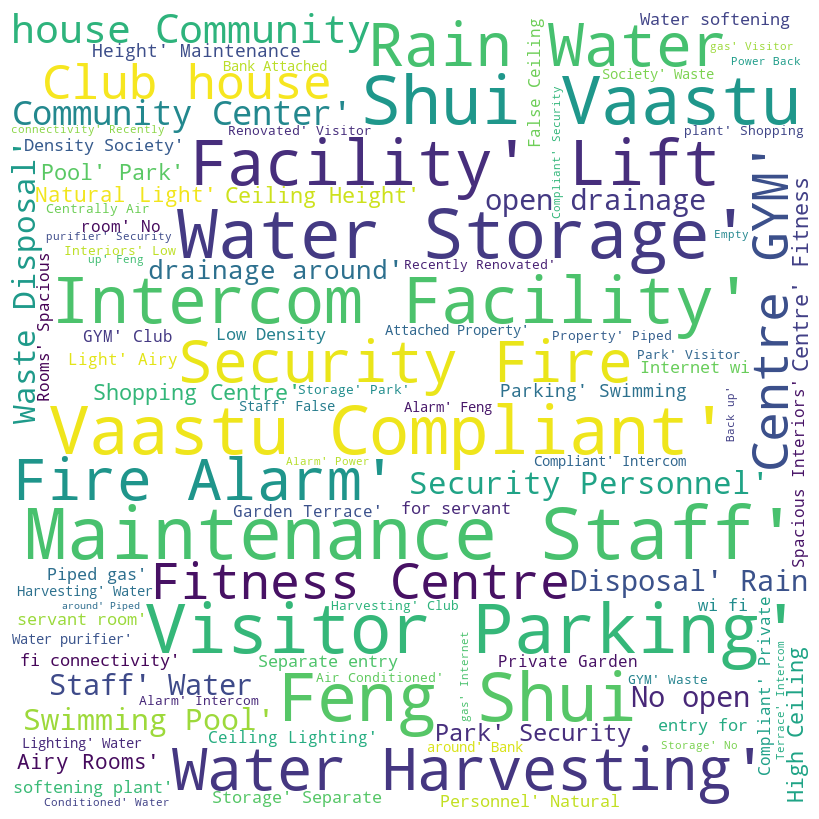

In [52]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),
                      min_font_size = 10).generate(main)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [39]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [40]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [41]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [42]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\puruc\AppData\Local\Temp\ipykernel_8524\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\puruc\AppData\Local\Temp\ipykernel_8524\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

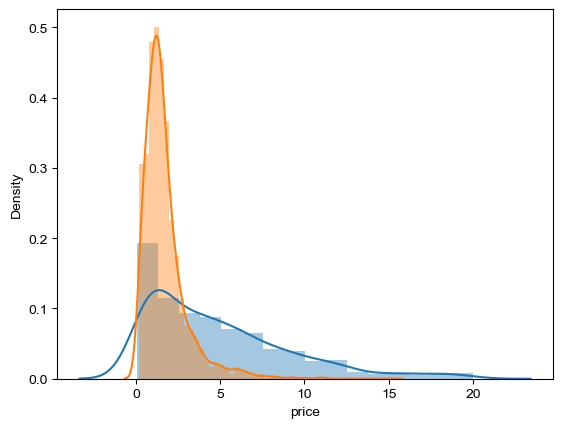

In [43]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [44]:
new_df['sector'].unique().tolist().insert(0,'overall')